# Projet 11 — La Poule qui chante
## Préparation et nettoyage des données

### Objectif
Ce notebook a pour objectif de préparer, nettoyer et enrichir les données utilisées pour identifier des marchés potentiels pour l'exportation de viande de volaille.

Les données alimentaires et démographiques fournies sont complétées par des indicateurs économiques et politiques issus de la Banque mondiale.

L'objectif final est d'obtenir un jeu de données propre contenant au minimum 100 pays et 8 variables pertinentes, qui sera ensuite utilisé pour l'ACP et le clustering.

In [68]:
import pandas as pd
import numpy as np

print("Environnement Python prêt !")
print("Pandas :", pd.__version__)

Environnement Python prêt !
Pandas : 2.3.3


## 1. Chargement et exploration des données

In [69]:
# Chargement des données

df_population = pd.read_csv("../P11/Population_2000_2018.csv")

df_dispo = pd.read_csv("../P11/DisponibiliteAlimentaire_2017.csv")

df_stabilite = pd.read_csv("../P11/stabilite_politique.csv")

df_pib = pd.read_csv(
    "../P11/PIB_analyse.csv",
    skiprows=4
)

In [70]:
# Aperçu des données
display(df_population.head())
display(df_dispo.head())
display(df_stabilite.head())
display(df_pib.head())

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_GOV_WGI_PV_SC,_T,_T,_T,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Index,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_GOV_WGI_PV_SC,_T,_T,_T,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Index,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_GOV_WGI_PV_SC,_T,_T,_T,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Index,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_GOV_WGI_PV_SC,_T,_T,_T,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Index,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_GOV_WGI_PV_SC,_T,_T,_T,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Index,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,38213.289239,39378.228411,39754.560072,30408.827090,35207.170909,39083.461640,42783.248907,45428.002728,NaN,NaN
1,NaN,AFE,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4223.188050,4229.839634,4200.531044,3978.133502,4049.969513,4098.126192,4076.224898,4099.889812,4164.679177,NaN
2,Afghanistan,AFG,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN,NaN
3,NaN,AFW,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,6009.516114,6026.527572,6070.284769,5698.766702,5702.134886,5818.483224,5886.796636,6009.084662,6139.587294,NaN
4,Angola,AGO,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,10565.167648,10154.838923,9712.979449,8904.949006,8720.187687,8750.993630,8597.538788,8752.797471,8760.190820,NaN


In [71]:
# Dimensions des jeux de données
print("Population :", df_population.shape)
print("Disponibilité alimentaire :", df_dispo.shape)
print("Stabilité politique :", df_stabilite.shape)
print("PIB par habitant :", df_pib.shape)

Population : (4411, 15)
Disponibilité alimentaire : (176600, 14)
Stabilité politique : (5229, 41)
PIB par habitant : (265, 71)


In [72]:
# Structure et types des données
df_population.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

In [73]:
df_dispo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

In [74]:
df_stabilite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5229 entries, 0 to 5228
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               5229 non-null   object 
 1   STRUCTURE_ID            5229 non-null   object 
 2   ACTION                  5229 non-null   object 
 3   FREQ                    5229 non-null   object 
 4   REF_AREA                5229 non-null   object 
 5   INDICATOR               5229 non-null   object 
 6   SEX                     5229 non-null   object 
 7   AGE                     5229 non-null   object 
 8   URBANISATION            5229 non-null   object 
 9   UNIT_MEASURE            5229 non-null   object 
 10  COMP_BREAKDOWN_1        5229 non-null   object 
 11  COMP_BREAKDOWN_2        5229 non-null   object 
 12  COMP_BREAKDOWN_3        5229 non-null   object 
 13  TIME_PERIOD             5229 non-null   int64  
 14  OBS_VALUE               5229 non-null   

In [75]:
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    263 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [76]:
# Valeurs manquantes
print("Population :", df_population.isna().sum())


Population : Code Domaine                 0
Domaine                      0
Code zone                    0
Zone                         0
Code Élément                 0
Élément                      0
Code Produit                 0
Produit                      0
Code année                   0
Année                        0
Unité                        0
Valeur                       0
Symbole                      0
Description du Symbole       0
Note                      4153
dtype: int64


In [77]:
print("Disponibilité alimentaire :", df_dispo.isna().sum())


Disponibilité alimentaire : Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64


In [78]:
print("Stabilité politique :", df_stabilite.isna().sum())

Stabilité politique : STRUCTURE                 0
STRUCTURE_ID              0
ACTION                    0
FREQ                      0
REF_AREA                  0
INDICATOR                 0
SEX                       0
AGE                       0
URBANISATION              0
UNIT_MEASURE              0
COMP_BREAKDOWN_1          0
COMP_BREAKDOWN_2          0
COMP_BREAKDOWN_3          0
TIME_PERIOD               0
OBS_VALUE                 0
AGG_METHOD                0
UNIT_TYPE                 0
DECIMALS                  0
DATABASE_ID               0
TIME_FORMAT               0
UNIT_MULT                 0
OBS_STATUS                0
OBS_CONF                  0
FREQ_LABEL                0
REF_AREA_LABEL            0
INDICATOR_LABEL           0
SEX_LABEL                 0
AGE_LABEL                 0
URBANISATION_LABEL        0
UNIT_MEASURE_LABEL        0
COMP_BREAKDOWN_1_LABEL    0
COMP_BREAKDOWN_2_LABEL    0
COMP_BREAKDOWN_3_LABEL    0
AGG_METHOD_LABEL          0
UNIT_TYPE_LABEL           

In [79]:
print("PIB :", df_pib.isna().sum())

PIB : Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960              265
                 ... 
2022               19
2023               21
2024               23
2025               33
Unnamed: 70       265
Length: 71, dtype: int64


## 2. Préparation et nettoyage des données

### 2.1 Préparation des données de population

In [80]:
# Sélection des colonnes utiles
population = df_population[
    ["Zone", "Année", "Valeur", "Unité"]
].copy()

# Conservation des années nécessaires
population = population[
    population["Année"].isin([2012, 2017])
]

# Vérification
display(population.head())
print(population.shape)
print(population["Année"].value_counts())
print(population["Unité"].value_counts())

,Zone,Année,Valeur,Unité
12,Afghanistan,2012,31161.376,1000 personnes
17,Afghanistan,2017,36296.113,1000 personnes
31,Afrique du Sud,2012,52832.658,1000 personnes
36,Afrique du Sud,2017,57009.756,1000 personnes
50,Albanie,2012,2914.096,1000 personnes


(472, 4)
Année
2012    236
2017    236
Name: count, dtype: int64
Unité
1000 personnes    472
Name: count, dtype: int64


In [81]:
population = population.pivot(
    index="Zone",
    columns="Année",
    values="Valeur"
).reset_index()

population.columns = [
    "Pays",
    "Population_2012",
    "Population_2017"
]

display(population.head())

,Pays,Population_2012,Population_2017
0,Afghanistan,31161.376,36296.113
1,Afrique du Sud,52832.658,57009.756
2,Albanie,2914.096,2884.169
3,Algérie,37383.895,41389.189
4,Allemagne,80972.628,82658.409


#### Création de la croissance démographique 2012–2017

In [82]:
population["Croissance_population_2012_2017_pct"] = (
    (population["Population_2017"] - population["Population_2012"])
    / population["Population_2012"]
) * 100

In [83]:
display(population.head())

print("Dimensions :", population.shape)
print("\nValeurs manquantes :")
print(population.isna().sum())

print("\nDoublons pays :", population["Pays"].duplicated().sum())

,Pays,Population_2012,Population_2017,Croissance_population_2012_2017_pct
0,Afghanistan,31161.376,36296.113,16.477889
1,Afrique du Sud,52832.658,57009.756,7.906280
2,Albanie,2914.096,2884.169,-1.026974
3,Algérie,37383.895,41389.189,10.713956
4,Allemagne,80972.628,82658.409,2.081915


Dimensions : (236, 4)

Valeurs manquantes :
Pays                                   0
Population_2012                        0
Population_2017                        0
Croissance_population_2012_2017_pct    0
dtype: int64

Doublons pays : 0


### 2.2 Préparation des données de disponibilité alimentaire

In [84]:
# Création d'une copie de travail
dispo = df_dispo.copy()

# Conservation uniquement des données concernant la viande de volailles
dispo = dispo[
    dispo["Produit"] == "Viande de Volailles"
].copy()

# Vérification des éléments disponibles pour la volaille
print(dispo["Élément"].unique())
print("\nNombre de lignes :", dispo.shape[0])

['Production' 'Importations - Quantité' 'Variation de stock'
 'Disponibilité intérieure' 'Pertes' 'Résidus' 'Nourriture'
 'Disponibilité alimentaire en quantité (kg/personne/an)'
 'Disponibilité alimentaire (Kcal/personne/jour)'
 'Disponibilité de protéines en quantité (g/personne/jour)'
 'Disponibilité de matière grasse en quantité (g/personne/jour)'
 'Exportations - Quantité' 'Alimentation pour touristes' 'Traitement'
 'Autres utilisations (non alimentaire)' 'Aliments pour animaux'
 'Semences']

Nombre de lignes : 2061


In [85]:
# Sélection des indicateurs utiles pour l'analyse
elements_utiles = [
    "Production",
    "Importations - Quantité",
    "Disponibilité intérieure",
    "Disponibilité alimentaire en quantité (kg/personne/an)"
]

dispo = dispo[
    dispo["Élément"].isin(elements_utiles)
].copy()

# Vérification
print(dispo["Élément"].value_counts())
print("\nUnités utilisées :")
print(dispo.groupby("Élément")["Unité"].unique())

Élément
Disponibilité alimentaire en quantité (kg/personne/an)    172
Importations - Quantité                                   170
Disponibilité intérieure                                  170
Production                                                168
Name: count, dtype: int64

Unités utilisées :
Élément
Disponibilité alimentaire en quantité (kg/personne/an)                    [kg]
Disponibilité intérieure                                  [Milliers de tonnes]
Importations - Quantité                                   [Milliers de tonnes]
Production                                                [Milliers de tonnes]
Name: Unité, dtype: object


In [86]:
dispo = dispo.pivot(
    index="Zone",
    columns="Élément",
    values="Valeur"
).reset_index()

dispo.columns.name = None

dispo = dispo.rename(columns={
    "Zone": "Pays",
    "Production": "Production_volaille",
    "Importations - Quantité": "Importations_volaille",
    "Disponibilité intérieure": "Disponibilite_interieure_volaille",
    "Disponibilité alimentaire en quantité (kg/personne/an)": "Disponibilite_volaille_kg_hab_an"
})

display(dispo.head())
print("Dimensions :", dispo.shape)
print("\nValeurs manquantes :")
print(dispo.isna().sum())
print("\nDoublons pays :", dispo["Pays"].duplicated().sum())

,Pays,Disponibilite_volaille_kg_hab_an,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille
0,Afghanistan,1.53,57.0,29.0,28.0
1,Afrique du Sud,35.69,2118.0,514.0,1667.0
2,Albanie,16.36,47.0,38.0,13.0
3,Algérie,6.38,277.0,2.0,275.0
4,Allemagne,19.47,1739.0,842.0,1514.0


Dimensions : (172, 5)

Valeurs manquantes :
Pays                                 0
Disponibilite_volaille_kg_hab_an     0
Disponibilite_interieure_volaille    2
Importations_volaille                2
Production_volaille                  4
dtype: int64

Doublons pays : 0


#### Création du taux de dépendance aux importations

In [87]:
dispo["Dependance_importations_pct"] = (
    dispo["Importations_volaille"]
    / dispo["Disponibilite_interieure_volaille"]
) * 100

In [88]:
display(dispo.head())

print("Valeurs manquantes :")
print(dispo.isna().sum())

print("\nStatistiques du taux de dépendance :")
print(dispo["Dependance_importations_pct"].describe())

,Pays,Disponibilite_volaille_kg_hab_an,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille,Dependance_importations_pct
0,Afghanistan,1.53,57.0,29.0,28.0,50.877193
1,Afrique du Sud,35.69,2118.0,514.0,1667.0,24.268178
2,Albanie,16.36,47.0,38.0,13.0,80.851064
3,Algérie,6.38,277.0,2.0,275.0,0.722022
4,Allemagne,19.47,1739.0,842.0,1514.0,48.418631


Valeurs manquantes :
Pays                                 0
Disponibilite_volaille_kg_hab_an     0
Disponibilite_interieure_volaille    2
Importations_volaille                2
Production_volaille                  4
Dependance_importations_pct          2
dtype: int64

Statistiques du taux de dépendance :
count    170.000000
mean      45.803811
std       51.850021
min        0.000000
25%        4.233163
50%       24.749473
75%       80.638298
max      323.928571
Name: Dependance_importations_pct, dtype: float64


### 2.3 Préparation des données de PIB par habitant

In [89]:
# Création d'une copie de travail
pib = df_pib.copy()

# Sélection des colonnes utiles et de l'année 2017
pib = pib[
    ["Country Name", "Country Code", "2017"]
].copy()

# Renommage des colonnes
pib = pib.rename(columns={
    "Country Name": "Pays",
    "Country Code": "Code_pays",
    "2017": "PIB_habitant_PPA"
})

# Vérifications
display(pib.head())

print("Dimensions :", pib.shape)
print("\nValeurs manquantes :")
print(pib.isna().sum())
print("\nDoublons codes pays :", pib["Code_pays"].duplicated().sum())

,Pays,Code_pays,PIB_habitant_PPA
0,Aruba,ABW,38213.289239
1,NaN,AFE,4223.188050
2,Afghanistan,AFG,2952.998916
3,NaN,AFW,6009.516114
4,Angola,AGO,10565.167648


Dimensions : (265, 3)

Valeurs manquantes :
Pays                 2
Code_pays            0
PIB_habitant_PPA    19
dtype: int64

Doublons codes pays : 0


### 2.4 Préparation des données de stabilité politique

In [90]:
# Création d'une copie de travail
stabilite = df_stabilite.copy()

# Conservation de l'année 2017
stabilite = stabilite[
    stabilite["TIME_PERIOD"] == 2017
].copy()

# Sélection des colonnes utiles
stabilite = stabilite[
    ["REF_AREA", "REF_AREA_LABEL", "OBS_VALUE"]
].copy()

# Renommage
stabilite = stabilite.rename(columns={
    "REF_AREA": "Code_pays",
    "REF_AREA_LABEL": "Pays",
    "OBS_VALUE": "Stabilite_politique"
})

# Vérifications
display(stabilite.head())

print("Dimensions :", stabilite.shape)
print("\nValeurs manquantes :")
print(stabilite.isna().sum())
print("\nDoublons codes pays :", stabilite["Code_pays"].duplicated().sum())

,Code_pays,Pays,Stabilite_politique
6,ZWE,Zimbabwe,51.633351
93,IND,India,56.121815
94,IDN,Indonesia,55.959485
95,IRN,"Iran, Islamic Rep.",53.946787
96,IRQ,Iraq,28.866178


Dimensions : (204, 3)

Valeurs manquantes :
Code_pays              0
Pays                   0
Stabilite_politique    0
dtype: int64

Doublons codes pays : 0


## 3. Fusion des jeux de données

### 3.1 Préparation des jeux de données avant fusion

In [91]:
# Fusion du PIB et de la stabilité politique à partir du code pays
donnees_bm = pib.merge(
    stabilite[["Code_pays", "Stabilite_politique"]],
    on="Code_pays",
    how="inner"
)

display(donnees_bm.head())

print("Dimensions :", donnees_bm.shape)
print("\nValeurs manquantes :")
print(donnees_bm.isna().sum())
print("\nDoublons codes pays :", donnees_bm["Code_pays"].duplicated().sum())

,Pays,Code_pays,PIB_habitant_PPA,Stabilite_politique
0,Aruba,ABW,38213.289239,86.506164
1,Afghanistan,AFG,2952.998916,21.244270
2,Angola,AGO,10565.167648,56.717910
3,Albanie,ALB,15359.397458,68.692869
4,Émirats arabes unis,ARE,72529.042351,78.180968


Dimensions : (204, 4)

Valeurs manquantes :
Pays                    0
Code_pays               0
PIB_habitant_PPA       10
Stabilite_politique     0
dtype: int64

Doublons codes pays : 0


In [92]:
# Fusion des données FAO : population et disponibilité alimentaire
donnees_fao = population.merge(
    dispo,
    on="Pays",
    how="inner"
)

print("Pays Population :", population["Pays"].nunique())
print("Pays Disponibilité :", dispo["Pays"].nunique())
print("Pays après fusion FAO :", donnees_fao["Pays"].nunique())

display(donnees_fao.head())

Pays Population : 236
Pays Disponibilité : 172
Pays après fusion FAO : 172


,Pays,Population_2012,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille,Dependance_importations_pct
0,Afghanistan,31161.376,36296.113,16.477889,1.53,57.0,29.0,28.0,50.877193
1,Afrique du Sud,52832.658,57009.756,7.906280,35.69,2118.0,514.0,1667.0,24.268178
2,Albanie,2914.096,2884.169,-1.026974,16.36,47.0,38.0,13.0,80.851064
3,Algérie,37383.895,41389.189,10.713956,6.38,277.0,2.0,275.0,0.722022
4,Allemagne,80972.628,82658.409,2.081915,19.47,1739.0,842.0,1514.0,48.418631


In [93]:
# Vérification de la correspondance des noms de pays
pays_fao = set(donnees_fao["Pays"])
pays_bm = set(donnees_bm["Pays"])

pays_communs = pays_fao.intersection(pays_bm)

print("Pays FAO :", len(pays_fao))
print("Pays Banque mondiale :", len(pays_bm))
print("Pays correspondant directement :", len(pays_communs))

print("\nExemples de pays FAO sans correspondance :")
print(sorted(pays_fao - pays_bm)[:30])

Pays FAO : 172
Pays Banque mondiale : 204
Pays correspondant directement : 151

Exemples de pays FAO sans correspondance :
['Bolivie (État plurinational de)', 'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao', 'Chine, Taiwan Province de', 'Chine, continentale', 'Congo', "Iran (République islamique d')", 'Kirghizistan', 'Nouvelle-Calédonie', 'Polynésie française', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'République de Corée', 'République de Moldova', 'République populaire démocratique de Corée', 'République-Unie de Tanzanie', 'Slovaquie', 'Tchéquie', 'Venezuela (République bolivarienne du)', 'Yémen', 'Égypte', "États-Unis d'Amérique"]


In [94]:
# Identification des pays présents dans les données FAO
# mais dont le nom ne correspond à aucun pays de la Banque mondiale
pays_fao_non_matches = sorted(pays_fao - pays_bm)

# Affichage du nombre de pays concernés
print("Nombre de pays FAO sans correspondance :", len(pays_fao_non_matches))
print()

# Affichage de la liste complète pour identifier les différences de nomenclature
for pays in pays_fao_non_matches:
    print(pays)

Nombre de pays FAO sans correspondance : 21

Bolivie (État plurinational de)
Chine - RAS de Hong-Kong
Chine - RAS de Macao
Chine, Taiwan Province de
Chine, continentale
Congo
Iran (République islamique d')
Kirghizistan
Nouvelle-Calédonie
Polynésie française
Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
République de Corée
République de Moldova
République populaire démocratique de Corée
République-Unie de Tanzanie
Slovaquie
Tchéquie
Venezuela (République bolivarienne du)
Yémen
Égypte
États-Unis d'Amérique


In [95]:
# Identification des pays présents dans les données Banque mondiale
# mais dont le nom ne correspond à aucun pays des données FAO
pays_bm_non_matches = sorted(pays_bm - pays_fao)

# Affichage du nombre de pays concernés
print("Nombre de pays Banque mondiale sans correspondance :", len(pays_bm_non_matches))
print()

# Affichage de la liste complète pour rechercher les équivalents des noms FAO
for pays in pays_bm_non_matches:
    print(pays)

Nombre de pays Banque mondiale sans correspondance : 53

Aruba
Bahreïn
Bermudes
Bhoutan
Bolivie
Brunéi Darussalam
Burundi
Chine
Chine, RAS de Hong Kong
Cisjordanie et Gaza
Comores
Congo, République du
Congo, République démocratique du
Corée, République de
Corée, République démocratique de
Groenland
Guam
Guinée équatoriale
Iran, République islamique d’
Kosovo
Libye
Liechtenstein
Micronésie, États fédérés de
Moldova
Monaco
Naoero
Palaos
Papouasie-Nouvelle-Guinée
Puerto Rico (US)
Qatar
Royaume-Uni
Région administrative spéciale de Macao, Chine
République arabe syrienne
République fédérale de Somalie
République kirghize
République slovaque
République tchèque
Saint-Marin
Samoa américaines
Seychelles
Singapour
Soudan du Sud
Tanzanie
Tonga
Tuvalu
Venezuela
Yémen, Rép. du
Égypte, République arabe d’
Érythrée
États-Unis
Îles Caïmans
Îles Marshall
Îles Vierges (EU)


In [96]:
# Affichage des pays FAO sans correspondance directe
print("=== PAYS FAO SANS CORRESPONDANCE ===\n")

for i, pays in enumerate(pays_fao_non_matches, start=1):
    print(f"{i}. {pays}")

=== PAYS FAO SANS CORRESPONDANCE ===

1. Bolivie (État plurinational de)
2. Chine - RAS de Hong-Kong
3. Chine - RAS de Macao
4. Chine, Taiwan Province de
5. Chine, continentale
6. Congo
7. Iran (République islamique d')
8. Kirghizistan
9. Nouvelle-Calédonie
10. Polynésie française
11. Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
12. République de Corée
13. République de Moldova
14. République populaire démocratique de Corée
15. République-Unie de Tanzanie
16. Slovaquie
17. Tchéquie
18. Venezuela (République bolivarienne du)
19. Yémen
20. Égypte
21. États-Unis d'Amérique


In [97]:
# Affichage des pays Banque mondiale sans correspondance directe
print("=== PAYS BANQUE MONDIALE SANS CORRESPONDANCE ===\n")

for i, pays in enumerate(pays_bm_non_matches, start=1):
    print(f"{i}. {pays}")

=== PAYS BANQUE MONDIALE SANS CORRESPONDANCE ===

1. Aruba
2. Bahreïn
3. Bermudes
4. Bhoutan
5. Bolivie
6. Brunéi Darussalam
7. Burundi
8. Chine
9. Chine, RAS de Hong Kong
10. Cisjordanie et Gaza
11. Comores
12. Congo, République du
13. Congo, République démocratique du
14. Corée, République de
15. Corée, République démocratique de
16. Groenland
17. Guam
18. Guinée équatoriale
19. Iran, République islamique d’
20. Kosovo
21. Libye
22. Liechtenstein
23. Micronésie, États fédérés de
24. Moldova
25. Monaco
26. Naoero
27. Palaos
28. Papouasie-Nouvelle-Guinée
29. Puerto Rico (US)
30. Qatar
31. Royaume-Uni
32. Région administrative spéciale de Macao, Chine
33. République arabe syrienne
34. République fédérale de Somalie
35. République kirghize
36. République slovaque
37. République tchèque
38. Saint-Marin
39. Samoa américaines
40. Seychelles
41. Singapour
42. Soudan du Sud
43. Tanzanie
44. Tonga
45. Tuvalu
46. Venezuela
47. Yémen, Rép. du
48. Égypte, République arabe d’
49. Érythrée
50. État

In [98]:
# Harmonisation des noms de pays FAO avec la nomenclature de la Banque mondiale
mapping_pays = {
    "Bolivie (État plurinational de)": "Bolivie",
    "Chine - RAS de Hong-Kong": "Chine, RAS de Hong Kong",
    "Chine - RAS de Macao": "Région administrative spéciale de Macao, Chine",
    "Chine, continentale": "Chine",
    "Congo": "Congo, République du",
    "Iran (République islamique d')": "Iran, République islamique d’",
    "Kirghizistan": "République kirghize",
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": "Royaume-Uni",
    "République de Corée": "Corée, République de",
    "République de Moldova": "Moldova",
    "République populaire démocratique de Corée": "Corée, République démocratique de",
    "République-Unie de Tanzanie": "Tanzanie",
    "Slovaquie": "République slovaque",
    "Tchéquie": "République tchèque",
    "Venezuela (République bolivarienne du)": "Venezuela",
    "Yémen": "Yémen, Rép. du",
    "Égypte": "Égypte, République arabe d’",
    "États-Unis d'Amérique": "États-Unis"
}

# Application du mapping uniquement sur le dataset FAO de travail
donnees_fao["Pays"] = donnees_fao["Pays"].replace(mapping_pays)

In [99]:
# Vérification des correspondances après harmonisation
pays_fao_apres = set(donnees_fao["Pays"])
pays_bm = set(donnees_bm["Pays"])

pays_non_matches_apres = sorted(pays_fao_apres - pays_bm)

print("Pays FAO :", len(pays_fao_apres))
print("Pays correspondant avec la Banque mondiale :",
      len(pays_fao_apres.intersection(pays_bm)))

print("\nPays FAO restant sans correspondance :")
for pays in pays_non_matches_apres:
    print(pays)

Pays FAO : 172
Pays correspondant avec la Banque mondiale : 169

Pays FAO restant sans correspondance :
Chine, Taiwan Province de
Nouvelle-Calédonie
Polynésie française


### 3.2 Fusion des données FAO et Banque mondiale

In [100]:
# Fusion des données FAO et Banque mondiale
# Seuls les pays présents dans les deux sources sont conservés
donnees_finales = donnees_fao.merge(
    donnees_bm,
    on="Pays",
    how="inner"
)

# Vérification de la fusion
display(donnees_finales.head())

print("Dimensions :", donnees_finales.shape)
print("\nNombre de pays :", donnees_finales["Pays"].nunique())

print("\nValeurs manquantes :")
print(donnees_finales.isna().sum())

print("\nDoublons pays :", donnees_finales["Pays"].duplicated().sum())

,Pays,Population_2012,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille,Dependance_importations_pct,Code_pays,PIB_habitant_PPA,Stabilite_politique
0,Afghanistan,31161.376,36296.113,16.477889,1.53,57.0,29.0,28.0,50.877193,AFG,2952.998916,21.244270
1,Afrique du Sud,52832.658,57009.756,7.906280,35.69,2118.0,514.0,1667.0,24.268178,ZAF,14573.598084,59.355008
2,Albanie,2914.096,2884.169,-1.026974,16.36,47.0,38.0,13.0,80.851064,ALB,15359.397458,68.692869
3,Algérie,37383.895,41389.189,10.713956,6.38,277.0,2.0,275.0,0.722022,DZA,15427.664189,50.016967
4,Allemagne,80972.628,82658.409,2.081915,19.47,1739.0,842.0,1514.0,48.418631,DEU,61965.434290,77.889508


Dimensions : (169, 12)

Nombre de pays : 169

Valeurs manquantes :
Pays                                   0
Population_2012                        0
Population_2017                        0
Croissance_population_2012_2017_pct    0
Disponibilite_volaille_kg_hab_an       0
Disponibilite_interieure_volaille      2
Importations_volaille                  2
Production_volaille                    4
Dependance_importations_pct            2
Code_pays                              0
PIB_habitant_PPA                       4
Stabilite_politique                    0
dtype: int64

Doublons pays : 0


### 3.3 Création des importations de volaille par habitant

In [101]:
# Calcul des importations de volaille par habitant
# Les importations et la population étant toutes deux exprimées en milliers,
# leur rapport donne des tonnes par personne, converties ensuite en kg/personne
donnees_finales["Importations_volaille_kg_hab"] = (
    donnees_finales["Importations_volaille"]
    / donnees_finales["Population_2017"]
) * 1000

In [102]:
# Vérification de la nouvelle variable
display(
    donnees_finales[
        ["Pays", "Importations_volaille",
         "Population_2017", "Importations_volaille_kg_hab"]
    ].head()
)

print(donnees_finales["Importations_volaille_kg_hab"].describe())

,Pays,Importations_volaille,Population_2017,Importations_volaille_kg_hab
0,Afghanistan,29.0,36296.113,0.798984
1,Afrique du Sud,514.0,57009.756,9.016001
2,Albanie,38.0,2884.169,13.175372
3,Algérie,2.0,41389.189,0.048322
4,Allemagne,842.0,82658.409,10.186501


count    167.000000
mean      10.656359
std       18.463657
min        0.000000
25%        0.399906
50%        3.434375
75%       11.619221
max      124.139068
Name: Importations_volaille_kg_hab, dtype: float64


## 4. Contrôle de la qualité des données

### 4.1 Analyse des valeurs manquantes

In [103]:
# Comptage des valeurs manquantes dans le dataset fusionné
valeurs_manquantes = donnees_finales.isna().sum()

# Affichage uniquement des colonnes contenant au moins une valeur manquante
print("Valeurs manquantes :")
print(valeurs_manquantes[valeurs_manquantes > 0])

Valeurs manquantes :
Disponibilite_interieure_volaille    2
Importations_volaille                2
Production_volaille                  4
Dependance_importations_pct          2
PIB_habitant_PPA                     4
Importations_volaille_kg_hab         2
dtype: int64


In [104]:
# Identification des pays présentant au moins une valeur manquante
lignes_nan = donnees_finales[
    donnees_finales.isna().any(axis=1)
]

display(lignes_nan)
print("Nombre de pays concernés :", len(lignes_nan))

,Pays,Population_2012,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille,Dependance_importations_pct,Code_pays,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
39,Cuba,11257.104,11339.254,0.729761,23.72,342.0,312.0,29.0,91.228070,CUB,NaN,75.681593,27.515038
42,Djibouti,868.137,944.099,8.750001,2.68,3.0,3.0,NaN,100.000000,DJI,5421.956491,52.993998,3.177633
91,Maldives,397.237,496.402,24.963687,13.50,12.0,12.0,NaN,100.000000,MDV,20036.716535,65.156839,24.173956
111,Ouzbékistan,29449.413,31959.785,8.524353,1.96,NaN,NaN,NaN,NaN,UZB,8413.299753,62.240996,NaN
127,République démocratique populaire lao,6444.530,6953.035,7.890490,10.91,NaN,NaN,NaN,NaN,LAO,7432.459633,70.637255,NaN
128,"Corée, République démocratique de",24800.645,25429.825,2.536950,1.62,43.0,0.0,43.0,0.000000,PRK,NaN,59.840915,0.000000
158,Venezuela,29360.837,29402.484,0.141845,20.28,626.0,25.0,600.0,3.993610,VEN,NaN,42.320681,0.850268
160,"Yémen, Rép. du",24473.178,27834.819,13.736022,8.53,246.0,78.0,168.0,31.707317,YEM,NaN,19.253039,2.802246


Nombre de pays concernés : 8


In [105]:
# Affichage des pays concernés et uniquement des variables
# présentant au moins une valeur manquante

colonnes_nan = [
    "Pays",
    "Disponibilite_interieure_volaille",
    "Importations_volaille",
    "Production_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Importations_volaille_kg_hab"
]

display(
    lignes_nan[colonnes_nan]
    .sort_values("Pays")
)

,Pays,Disponibilite_interieure_volaille,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Importations_volaille_kg_hab
128,"Corée, République démocratique de",43.0,0.0,43.0,0.000000,NaN,0.000000
39,Cuba,342.0,312.0,29.0,91.228070,NaN,27.515038
42,Djibouti,3.0,3.0,NaN,100.000000,5421.956491,3.177633
91,Maldives,12.0,12.0,NaN,100.000000,20036.716535,24.173956
111,Ouzbékistan,NaN,NaN,NaN,NaN,8413.299753,NaN
127,République démocratique populaire lao,NaN,NaN,NaN,NaN,7432.459633,NaN
158,Venezuela,626.0,25.0,600.0,3.993610,NaN,0.850268
160,"Yémen, Rép. du",246.0,78.0,168.0,31.707317,NaN,2.802246


In [106]:
# Nombre de valeurs manquantes par pays
nb_nan_par_pays = (
    lignes_nan
    .set_index("Pays")
    .isna()
    .sum(axis=1)
    .sort_values(ascending=False)
)

display(nb_nan_par_pays)

Pays
Ouzbékistan                              5
République démocratique populaire lao    5
Cuba                                     1
Djibouti                                 1
Maldives                                 1
Corée, République démocratique de        1
Venezuela                                1
Yémen, Rép. du                           1
dtype: int64

In [107]:
# Suppression des observations présentant des valeurs manquantes
# Aucune imputation n'est réalisée afin de ne pas introduire
# de valeurs artificielles dans l'analyse multivariée.
donnees_finales = donnees_finales.dropna().copy()

# Vérification après traitement
print("Dimensions après traitement :", donnees_finales.shape)
print("Nombre de pays :", donnees_finales["Pays"].nunique())
print("Nombre total de valeurs manquantes :", donnees_finales.isna().sum().sum())

Dimensions après traitement : (161, 13)
Nombre de pays : 161
Nombre total de valeurs manquantes : 0


Les observations présentant des valeurs manquantes ont été exclues du jeu de données final. 
Compte tenu du nombre limité de pays concernés et de la taille restante de l'échantillon, 
aucune imputation n'a été réalisée afin d'éviter l'introduction de valeurs artificielles 
susceptibles d'influencer l'ACP et les méthodes de clustering.

### 4.2 Vérification des doublons et des valeurs incohérentes

In [108]:
# Vérification des doublons
print("Doublons complets :", donnees_finales.duplicated().sum())
print("Doublons sur les pays :", donnees_finales["Pays"].duplicated().sum())

# Vérification des valeurs infinies dans les variables numériques
colonnes_numeriques = donnees_finales.select_dtypes(include=np.number).columns

print(
    "Valeurs infinies :",
    np.isinf(donnees_finales[colonnes_numeriques]).sum().sum()
)

# Vérification des valeurs négatives
for colonne in colonnes_numeriques:
    nb_negatives = (donnees_finales[colonne] < 0).sum()
    if nb_negatives > 0:
        print(f"{colonne} : {nb_negatives} valeur(s) négative(s)")

Doublons complets : 0
Doublons sur les pays : 0
Valeurs infinies : 0
Croissance_population_2012_2017_pct : 18 valeur(s) négative(s)


## 5. Analyse exploratoire du jeu de données final

### 5.1 Statistiques descriptives

In [109]:
# Sélection des variables numériques du dataset final
variables_numeriques = donnees_finales.select_dtypes(include=np.number)

# Statistiques descriptives
display(variables_numeriques.describe().T)

,count,mean,std,min,25%,50%,75%,max
Population_2012,161.0,42311.446882,151636.648936,49.887000,2884.234000,9264.692000,29154.900000,1.384206e+06
Population_2017,161.0,44783.815540,158015.405860,52.045000,2920.848000,9729.823000,31444.298000,1.421022e+06
Croissance_population_2012_2017_pct,161.0,7.019528,6.527786,-7.030485,2.384357,5.862380,11.557978,3.338734e+01
Disponibilite_volaille_kg_hab_an,161.0,20.336770,15.909245,0.130000,6.460000,18.200000,29.950000,7.231000e+01
Disponibilite_interieure_volaille,161.0,713.093168,2244.124506,2.000000,32.000000,102.000000,372.000000,1.826600e+04
Importations_volaille,161.0,90.714286,190.332651,0.000000,3.000000,16.000000,82.000000,1.069000e+03
Production_volaille,161.0,747.440994,2552.641874,0.000000,14.000000,71.000000,392.000000,2.191400e+04
Dependance_importations_pct,161.0,45.076964,52.285398,0.000000,4.194941,24.242424,78.125000,3.239286e+02
PIB_habitant_PPA,161.0,23921.083776,23700.149706,1103.866093,5993.630852,15554.658743,33828.714943,1.333226e+05
Stabilite_politique,161.0,64.860049,14.526549,21.244270,55.608984,65.806607,77.567896,9.138842e+01


### 5.2 Analyse des valeurs atypiques

In [110]:
# Identification des pays présentant les valeurs les plus élevées
# sur les principales variables quantitatives

variables_extremes = [
    "Population_2017",
    "Disponibilite_interieure_volaille",
    "Importations_volaille",
    "Production_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Importations_volaille_kg_hab"
]

for variable in variables_extremes:
    print(f"\n--- {variable} ---")
    
    display(
        donnees_finales[
            ["Pays", variable]
        ]
        .sort_values(variable, ascending=False)
        .head(5)
    )


--- Population_2017 ---


,Pays,Population_2017
33,Chine,1421021.791
65,Inde,1338676.785
166,États-Unis,325084.756
66,Indonésie,264650.963
112,Pakistan,207906.209



--- Disponibilite_interieure_volaille ---


,Pays,Disponibilite_interieure_volaille
166,États-Unis,18266.0
33,Chine,18161.0
21,Brésil,9982.0
51,Fédération de Russie,4556.0
97,Mexique,4219.0



--- Importations_volaille ---


...

,Pays,Dependance_importations_pct
31,"Chine, RAS de Hong Kong",323.928571
16,Belgique,222.368421
149,Timor-Leste,220.000000
168,Îles Salomon,200.000000
53,Gambie,200.000000



--- PIB_habitant_PPA ---


,Pays,PIB_habitant_PPA
32,"Région administrative spéciale de Macao, Chine",133322.632678
86,Luxembourg,132169.829576
106,Norvège,89664.908642
69,Irlande,87731.789705
141,Suisse,79333.743781



--- Importations_volaille_kg_hab ---


,Pays,Importations_volaille_kg_hab
31,"Chine, RAS de Hong Kong",124.139068
133,Samoa,87.022401
131,Saint-Vincent-et-les Grenadines,81.947062
130,Saint-Kitts-et-Nevis,76.856566
6,Antigua-et-Barbuda,73.355270


L'analyse des valeurs extrêmes montre qu'elles correspondent principalement à des caractéristiques structurelles réelles des pays et non à des erreurs de données. Les pays les plus peuplés ou les plus grands producteurs présentent naturellement des volumes très élevés, tandis que certains petits territoires affichent des importations très importantes rapportées à leur population.

Ces observations sont donc conservées. Elles apportent une information pertinente pour l'analyse du potentiel des marchés internationaux. Une attention particulière sera néanmoins portée à leur influence lors de l'analyse multivariée.

### 5.3 Analyse de la distribution des variables

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

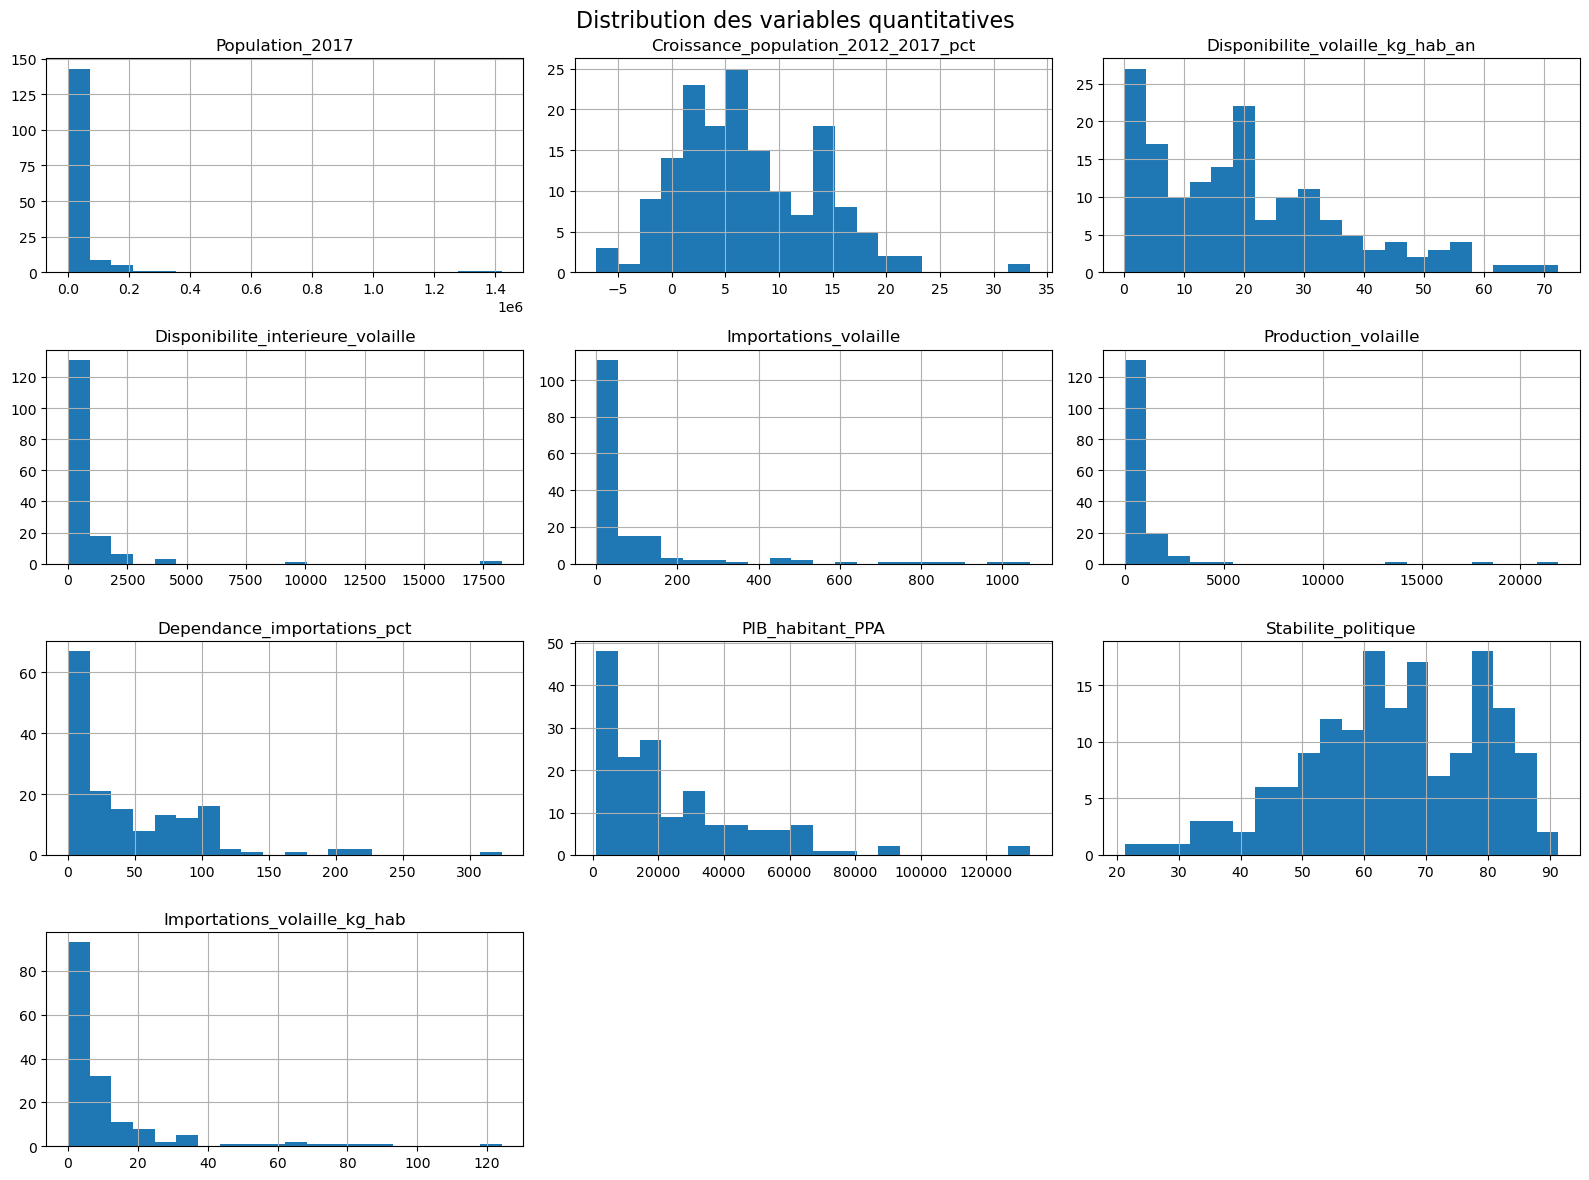

In [112]:
# Variables retenues pour l'analyse exploratoire
variables_analyse = [
    "Population_2017",
    "Croissance_population_2012_2017_pct",
    "Disponibilite_volaille_kg_hab_an",
    "Disponibilite_interieure_volaille",
    "Importations_volaille",
    "Production_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Stabilite_politique",
    "Importations_volaille_kg_hab"
]

# Visualisation des distributions
donnees_finales[variables_analyse].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle("Distribution des variables quantitatives", fontsize=16)
plt.tight_layout()
plt.show()

L'analyse des distributions met en évidence une forte hétérogénéité entre les variables.

La population, la production, les importations et la disponibilité intérieure de volaille présentent des distributions fortement asymétriques à droite : la majorité des pays affichent des valeurs relativement faibles, tandis que quelques grands pays concentrent des volumes très élevés.

Les indicateurs relatifs aux importations présentent également une asymétrie importante, certains pays ayant un recours particulièrement élevé aux importations.

À l'inverse, la croissance démographique présente une distribution plus symétrique, tandis que la disponibilité de volaille par habitant et la stabilité politique sont davantage réparties sur leurs plages de valeurs.

Ces différences de distribution et d'échelle devront être prises en compte lors de l'analyse multivariée.

### 5.4 Analyse des corrélations

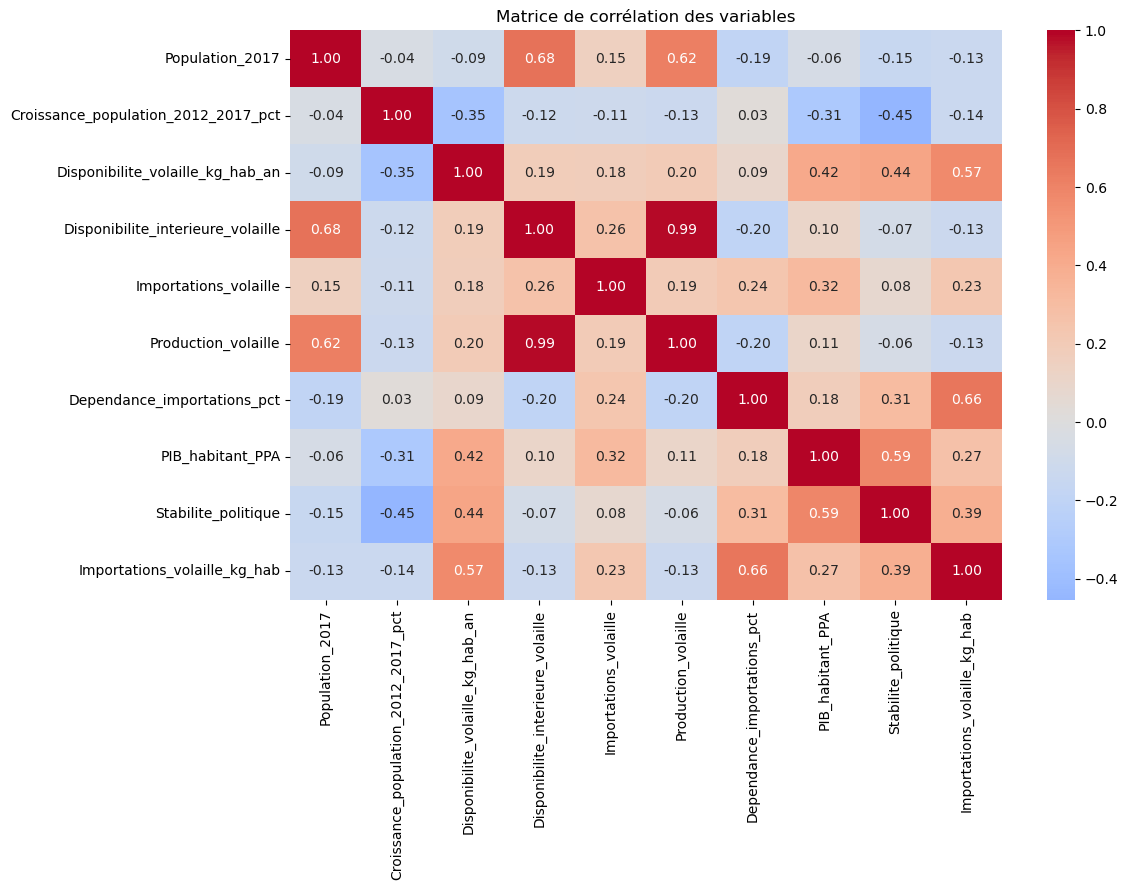

In [113]:
# Matrice de corrélation
correlations = donnees_finales[variables_analyse].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

L'analyse des corrélations met en évidence plusieurs relations importantes entre les variables.

La production de volaille et la disponibilité intérieure présentent une corrélation quasi parfaite (r = 0,99), indiquant une forte redondance entre ces deux indicateurs.

La population est également positivement corrélée à la disponibilité intérieure (r = 0,68) et à la production (r = 0,62), ce qui traduit l'importance de la taille démographique dans les volumes du marché avicole.

Les indicateurs relatifs aux importations présentent également des relations positives, notamment entre la dépendance aux importations et les importations par habitant (r = 0,66).

Enfin, le PIB par habitant et la stabilité politique présentent une corrélation positive (r = 0,59). Ces relations constituent des associations statistiques et ne doivent pas être interprétées comme des liens de causalité.

La matrice met ainsi en évidence plusieurs dimensions complémentaires du marché : taille du marché, recours aux importations et environnement économique et institutionnel.

### Analyse des valeurs aberrantes

Les distributions précédentes montrent que plusieurs variables présentent des valeurs
extrêmes. Dans un contexte international, ces observations ne correspondent pas
nécessairement à des erreurs : certains pays peuvent réellement présenter des niveaux
de population, de production ou d'importations très éloignés de la majorité.

Les valeurs aberrantes sont donc identifiées à l'aide de la méthode de l'IQR afin
d'évaluer leur importance et de déterminer si elles nécessitent un traitement
particulier.

In [122]:
# Variables quantitatives utilisées dans l'analyse
variables_analyse = [
    "Population_2017",
    "Croissance_population_2012_2017_pct",
    "Disponibilite_volaille_kg_hab_an",
    "Importations_volaille",
    "Production_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Stabilite_politique",
    "Importations_volaille_kg_hab"
]

resume_outliers = []

for variable in variables_analyse:
    q1 = donnees_finales[variable].quantile(0.25)
    q3 = donnees_finales[variable].quantile(0.75)
    
    iqr = q3 - q1
    
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    
    masque_outliers = (
        (donnees_finales[variable] < borne_inf)
        | (donnees_finales[variable] > borne_sup)
    )
    
    resume_outliers.append({
        "Variable": variable,
        "Nb_valeurs_aberrantes": masque_outliers.sum(),
        "Pourcentage": round(masque_outliers.mean() * 100, 2)
    })

resume_outliers = pd.DataFrame(resume_outliers)

display(resume_outliers)

,Variable,Nb_valeurs_aberrantes,Pourcentage
0,Population_2017,18,11.18
1,Croissance_population_2012_2017_pct,1,0.62
2,Disponibilite_volaille_kg_hab_an,2,1.24
3,Importations_volaille,18,11.18
4,Production_volaille,30,18.63
5,Dependance_importations_pct,5,3.11
6,PIB_habitant_PPA,5,3.11
7,Stabilite_politique,1,0.62
8,Importations_volaille_kg_hab,16,9.94


In [127]:
# Identification des observations extrêmes pour quelques variables structurantes
for variable in [
    "Population_2017",
    "Production_volaille",
    "Importations_volaille",
    "Dependance_importations_pct"
]:
    q1 = donnees_finales[variable].quantile(0.25)
    q3 = donnees_finales[variable].quantile(0.75)
    iqr = q3 - q1

    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    outliers = donnees_finales.loc[
        (donnees_finales[variable] < borne_inf)
        | (donnees_finales[variable] > borne_sup),
        ["Pays", variable]
    ].sort_values(variable, ascending=False)

    print(f"\n--- {variable} ---")
    display(outliers.head(10))


--- Population_2017 ---


,Pays,Population_2017
33,Chine,1421021.791
65,Inde,1338676.785
166,États-Unis,325084.756
66,Indonésie,264650.963
112,Pakistan,207906.209
21,Brésil,207833.823
105,Nigéria,190873.244
14,Bangladesh,159685.424
51,Fédération de Russie,145530.082
74,Japon,127502.725



--- Production_volaille ---


,Pays,Production_volaille
166,États-Unis,21914.0
33,Chine,18236.0
21,Brésil,14201.0
51,Fédération de Russie,4444.0
65,Inde,3545.0
97,Mexique,3249.0
117,Pologne,2351.0
66,Indonésie,2301.0
74,Japon,2215.0
154,Turquie,2192.0



--- Importations_volaille ---


,Pays,Importations_volaille
74,Japon,1069.0
97,Mexique,972.0
31,"Chine, RAS de Hong Kong",907.0
4,Allemagne,842.0
121,Royaume-Uni,779.0
7,Arabie saoudite,722.0
115,Pays-Bas,608.0
1,Afrique du Sud,514.0
50,France,506.0
68,Iraq,470.0



--- Dependance_importations_pct ---


,Pays,Dependance_importations_pct
31,"Chine, RAS de Hong Kong",323.928571
16,Belgique,222.368421
149,Timor-Leste,220.000000
53,Gambie,200.000000
168,Îles Salomon,200.000000


In [128]:
variables_finales = [
    "Population_2017",
    "Croissance_population_2012_2017_pct",
    "Disponibilite_volaille_kg_hab_an",
    "Importations_volaille",
    "Production_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Stabilite_politique",
    "Importations_volaille_kg_hab"
]

print("Nombre de variables retenues :", len(variables_finales))

Nombre de variables retenues : 9


### 5.5 Sélection des variables pour l'analyse multivariée

Neuf variables quantitatives ont été retenues pour l'ACP et le clustering.

La variable `Disponibilite_interieure_volaille` n'a pas été retenue pour l'analyse multivariée en raison de sa très forte corrélation avec la production de volaille (r = 0,99). La variable `Production_volaille` a été conservée car elle permet notamment de caractériser la capacité de production et la concurrence locale sur les marchés étudiés.

La variable `Population_2012` n'est pas utilisée directement dans l'analyse multivariée : elle a servi à construire l'indicateur de croissance démographique entre 2012 et 2017.

Les variables retenues permettent ainsi de représenter plusieurs dimensions complémentaires : taille du marché, dynamique démographique, consommation de volaille, production locale, recours aux importations, niveau économique et stabilité politique.

In [129]:
zones_2017 = df_population[
    df_population["Année"] == 2017
]["Zone"].unique()

print("Nombre de zones en 2017 :", len(zones_2017))
print(sorted(zones_2017))

Nombre de zones en 2017 : 236
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Andorre', 'Angola', 'Anguilla', 'Antigua-et-Barbuda', 'Antilles néerlandaises (ex)', 'Arabie saoudite', 'Argentine', 'Arménie', 'Aruba', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bahreïn', 'Bangladesh', 'Barbade', 'Belgique', 'Belize', 'Bermudes', 'Bhoutan', 'Bolivie (État plurinational de)', 'Bonaire, Saint-Eustache et Saba', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Brésil', 'Bulgarie', 'Burkina Faso', 'Burundi', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Canada', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao', 'Chine, Taiwan Province de', 'Chine, continentale', 'Chypre', 'Colombie', 'Comores', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', 'Curaçao', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Espagne', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'France', 'Fédération de Russie', 'Gabon', 'Gambie', 'Ghana', 'Gib

In [130]:
# Population totale des pays présents dans le fichier FAO en 2017
population_reference = (
    df_population[
        df_population["Année"] == 2017
    ]
    .drop_duplicates(subset="Zone")["Valeur"]
    .sum()
)

# Population des 161 pays conservés
population_couverte = donnees_finales["Population_2017"].sum()

# Couverture
couverture_population = (
    population_couverte / population_reference
) * 100

print(f"Population de référence : {population_reference:,.0f}")
print(f"Population couverte : {population_couverte:,.0f}")
print(f"Couverture : {couverture_population:.1f} %")

Population de référence : 7,548,134
Population couverte : 7,210,194
Couverture : 95.5 %


### Couverture démographique

Les 161 pays conservés dans le jeu de données final représentent 95,5 % de la population totale recensée dans le fichier démographique FAO pour l'année 2017.

Cette couverture est largement supérieure au seuil de 60 % recommandé pour le projet et garantit une représentation géographique suffisamment large pour l'analyse multivariée.

In [131]:
# Création du jeu de données destiné à l'analyse multivariée
donnees_analyse = donnees_finales[
    ["Pays"] + variables_finales
].copy()

print("Dimensions du dataset d'analyse :", donnees_analyse.shape)
display(donnees_analyse.head())

# Export
donnees_analyse.to_csv(
    "../P11/donnees_analyse_P11.csv",
    index=False
)

Dimensions du dataset d'analyse : (161, 10)


,Pays,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
0,Afghanistan,36296.113,16.477889,1.53,29.0,28.0,50.877193,2952.998916,21.244270,0.798984
1,Afrique du Sud,57009.756,7.906280,35.69,514.0,1667.0,24.268178,14573.598084,59.355008,9.016001
2,Albanie,2884.169,-1.026974,16.36,38.0,13.0,80.851064,15359.397458,68.692869,13.175372
3,Algérie,41389.189,10.713956,6.38,2.0,275.0,0.722022,15427.664189,50.016967,0.048322
4,Allemagne,82658.409,2.081915,19.47,842.0,1514.0,48.418631,61965.434290,77.889508,10.186501


## Conclusion

La préparation des données a permis de constituer un jeu de données final exploitable pour l'analyse multivariée.

Après nettoyage, harmonisation et fusion des différentes sources, 161 pays ont été conservés. Neuf variables quantitatives ont été sélectionnées afin de représenter plusieurs dimensions du potentiel des marchés : démographie, consommation de volaille, production locale, importations, niveau économique et stabilité politique.

Trois nouvelles variables ont également été créées : la croissance démographique entre 2012 et 2017, la dépendance aux importations et les importations de volaille par habitant.

L'analyse exploratoire a permis d'identifier les principales valeurs atypiques, d'étudier les distributions et les corrélations entre les variables. Les données sont désormais prêtes pour l'ACP et les méthodes de clustering.